# Lecture 8: Neural Network Theory - From Biological Neurons to Artificial Intelligence

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and python code that implements them -- just like you would see in a textbook. Of course, in a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
But this notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try out changing the code that you see**. In fact, in many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**. 
<br />

### Change everything
But don't feel limited to only change code when I prompt you. This notebook is your learning environment and your playground. I encourage you to try changing and running all the code throughout the notebook and even to **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with or trying to do is really helpful to understand what you were thinking when you revisit it later. 
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, I will ask the same set of questions to try to elicit your questions, reaction and feedback. When we review the reading notebook in class, I encourage you to share these.
</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Understand how artificial neurons are inspired by biological neurons
- Learn the mathematical model of a single artificial neuron
- Implement a simple single-layer neural network from scratch
- Understand gradient descent and backpropagation algorithms
- Gain qualitative understanding of architecture choices, activation functions, loss functions, and optimizers
- Build intuition for why neural networks work

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🧠
  </span>

  This lecture takes you on a journey from the neurons in your brain to the artificial neurons powering modern AI. We'll build a neural network from scratch to understand what's really happening inside these "black boxes." **By the end, you'll understand not just how neural networks work, but why they work!**
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

# 8.0 Code Preface

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

# Set plot style
plt.style.use('default')

# 8.1 From Biology to Artificial Neurons

<img alt="Biological neuron with dendrites, soma, axon and synapses labeled" src="../images/L08_biological_neuron.jpg" width="800" style="display:block;">
<font size=2>A biological neuron receives signals through dendrites, processes them in the soma (cell body), and transmits output through the axon.</font>

The human brain contains approximately **86 billion neurons**, each connected to thousands of others. These biological neurons inspired the artificial neurons that power modern AI.

## How Biological Neurons Work

A biological neuron has four main parts:

1. **Dendrites**: Receive electrical signals from other neurons
2. **Soma (cell body)**: Processes incoming signals by summing them up
3. **Axon**: Transmits the output signal to other neurons
4. **Synapses**: Connection points where neurons communicate (with varying **strengths**)

When the combined input exceeds a **threshold**, the neuron "fires" and sends a signal down its axon. The strength of each connection (synapse) can vary—this is how the brain learns!

## The Artificial Neuron

The artificial neuron mimics this biological process:

| Biological | Artificial |
|------------|------------|
| Dendrites receive signals | Input values (features) |
| Synapse strengths | Weights |
| Soma sums signals | Weighted sum + bias |
| Threshold for firing | Activation function |
| Axon output | Output value |

The first artificial neuron model, the **McCulloch-Pitts neuron** (1943), could only output 0 or 1. The **Perceptron** (1958) added learnable weights, enabling machines to learn from data.

# 8.2 Mathematical Model of a Neuron

<img alt="Diagram showing artificial neuron with inputs, weights, summation, activation function, and output" src="../images/L08_artificial_neuron_math.png" width="800" style="display:block;">
<font size=2>An artificial neuron: inputs are multiplied by weights, summed with a bias, and passed through an activation function.</font>

An artificial neuron computes:

$$y = f\left(\sum_{i=1}^{n} w_i x_i + b\right) = f(\mathbf{w} \cdot \mathbf{x} + b)$$

Where:
- $x_i$ = input features
- $w_i$ = weights (learned parameters)
- $b$ = bias (another learned parameter)
- $f$ = activation function (may contain learned parameters)

If you haven't seen linear algebra (vectors and matrices) before, you can think of the argument of this function $( \mathbf{w} \cdot \mathbf{x} + b )$ as the multi-dimensional version of a line  $( m*x + b )$. The dot product $(\cdot)$ is just a compact way of writing the weighted sum.

Let's code a single neuron:

In [2]:
def single_neuron(x, weights, bias, activation_fn):
    """
    Compute the output of a single neuron.
    
    Parameters:
    -----------
    x : array-like, shape (n_features,)
        Input values
    weights : array-like, shape (n_features,)
        Weight for each input
    bias : float
        Bias term
    activation_fn : callable
        Activation function to apply
    
    Returns:
    --------
    float : The neuron's output
    """
    # Step 1: Compute weighted sum
    weighted_sum = np.dot(weights, x) + bias
    
    # Step 2: Apply activation function
    output = activation_fn(weighted_sum)
    
    return output

# Example: A neuron with 3 inputs
x = np.array([0.5, 0.3, 0.2])  # Input features
w = np.array([0.4, -0.2, 0.6]) # Weights
b = 0.1                         # Bias

# Simple step activation (like McCulloch-Pitts)
step_activation = lambda z: 1 if z > 0 else 0

output = single_neuron(x, w, b, step_activation)
print(f"Inputs: {x}")
print(f"Weights: {w}")
print(f"Bias: {b}")
print(f"Weighted sum: {np.dot(w, x) + b:.3f}")
print(f"Neuron output: {output}")

Inputs: [0.5 0.3 0.2]
Weights: [ 0.4 -0.2  0.6]
Bias: 0.1
Weighted sum: 0.360
Neuron output: 1


## Why Activation Functions?

Without activation functions, a neural network is just a linear transformation—no matter how many layers you stack, you get the same result as a single linear transformation. **Non-linear activation functions** give neural networks the power to learn complex patterns.

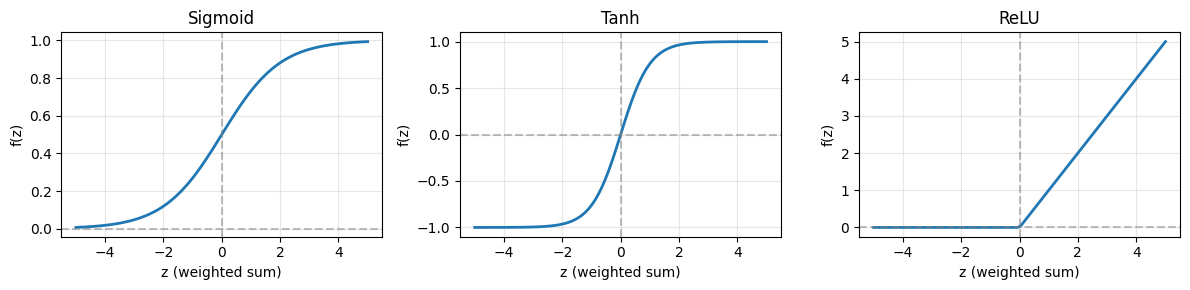

In [3]:
# Define common activation functions
def sigmoid(z):
    """Squashes values to range (0, 1) - good for probabilities"""
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Squashes values to range (-1, 1) - centered around zero"""
    return np.tanh(z)

def relu(z):
    """ReLU: Returns max(0, z) - simple and effective"""
    return np.maximum(0, z)

# Visualize them
z = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, (name, fn) in zip(axes, [('Sigmoid', sigmoid), ('Tanh', tanh), ('ReLU', relu)]):
    ax.plot(z, fn(z), linewidth=2)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('z (weighted sum)')
    ax.set_ylabel('f(z)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Quick summary of activation functions:**
- **Sigmoid**: Outputs (0,1), historically popular, but can cause "vanishing gradients"
- **Tanh**: Outputs (-1,1), centered at zero (better than sigmoid for hidden layers)
- **ReLU**: Most popular today—simple, fast, and works well in practice

<!-- Start Exercise 8.1-->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 8.1: Calculate Neuron Output </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
Given the following inputs, weights, and bias:
<ul>
<li>Inputs: x = [1.0, 2.0, -1.0]</li>
<li>Weights: w = [0.5, -0.5, 0.3]</li>
<li>Bias: b = 0.2</li>
</ul>

Calculate the input and output for each of the activation functions (sigmoid, tanh, relu) and print it out. Change the bias by large amounts to see how it affects the output.
</div>

In [4]:
# Exercise 8.1: Calculate Neuron Output

# Define the three common activation functions again for clarity
def sigmoid(z):
    """Squashes values to range (0, 1) - good for probabilities"""
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Squashes values to range (-1, 1) - centered around zero"""
    return np.tanh(z)

def relu(z):
    """ReLU: Returns max(0, z) - simple and effective"""
    return np.maximum(0, z)


# 1.  Create inputs, weights, and bias arrays
inputs = np.array([1.0,2.0,-1.0])
weights = np.array([0.5,-0.5,0.3])
bias = 0.2

# 2. Calculated the weighted sum + bias (the input to the activation function)
weighted_sum = np.dot(inputs,weights)+bias

# 3. Pass the weighted sum through the three different activation functions to get the final output for each and print it
output_sigmoid = sigmoid(weighted_sum)
output_tanh = tanh(weighted_sum) 
output_relu = relu(weighted_sum)

print(f"{output_sigmoid=}")
print(f"{output_tanh=}")
print(f"{output_relu=}")

# 4. Repeat, the above but try changing the bias by large amounts to see how it affects the output
# YOUR CODE HERE

output_sigmoid=0.35434369377420455
output_tanh=-0.5370495669980353
output_relu=0.0


<hr/>
<!-- End Exercise 8.1-->

# 8.3 Building a Simple Neural Network

Let's build a single-layer neural network (perceptron) to classify whether an animal is a cat. We'll use a tiny dataset of 8 animals with 4 features each:

In [5]:
import pandas as pd

# Create our "Is it a Cat?" dataset as a DataFrame
animals_df = pd.DataFrame({
    'animal': ['Cat', 'Dog', 'Cat', 'Hamster', 'Dog', 'Cat', 'Human', 'Cat'],
    'weight_kg': [4.5, 30.0, 3.8, 0.5, 25.0, 5.0, 70.0, 4.0],
    'height_cm': [25, 60, 22, 15, 55, 28, 100, 24],
    'has_whiskers': [1, 0, 1, 1, 0, 1, 0, 1],
    'purrs': [1, 0, 1, 0, 0, 1, 0, 0],
    'is_cat': [1, 0, 1, 0, 0, 1, 0, 1]
})

print("Our 'Is it a Cat?' dataset:")
display(animals_df)

Our 'Is it a Cat?' dataset:


,animal,weight_kg,height_cm,has_whiskers,purrs,is_cat
0,Cat,4.5,25,1,1,1
1,Dog,30.0,60,0,0,0
2,Cat,3.8,22,1,1,1
3,Hamster,0.5,15,1,0,0
4,Dog,25.0,55,0,0,0
5,Cat,5.0,28,1,1,1
6,Human,70.0,100,0,0,0
7,Cat,4.0,24,1,0,1


In [6]:
# Extract features (X) and labels (y) as numpy arrays for our neural network
feature_names = ['weight_kg', 'height_cm', 'has_whiskers', 'purrs']
X = animals_df[feature_names].values
y = animals_df['is_cat'].values

print(f"Feature matrix X shape: {X.shape}")
print(f"Label vector y shape: {y.shape}")
print(f"Features: {feature_names}")

Feature matrix X shape: (8, 4)
Label vector y shape: (8,)
Features: ['weight_kg', 'height_cm', 'has_whiskers', 'purrs']


## Normalizing Features

Before training, we should normalize our features so they're on similar scales. Otherwise, features with large values (like height) will dominate the learning.

In [7]:
# Normalize features to mean=0, std=1
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

print("Original first sample:", X[0])
print("Normalized first sample:", X_normalized[0].round(3))

Original first sample: [ 4.5 25.   1.   1. ]
Normalized first sample: [-0.601 -0.599  0.775  1.291]


In [8]:
X_normalized

array([[-0.60064794, -0.59944264,  0.77459667,  1.29099445],
       [ 0.54665711,  0.70167317, -1.29099445, -0.77459667],
       [-0.63214258, -0.71096685,  0.77459667,  1.29099445],
       [-0.78061736, -0.97119001,  0.77459667, -0.77459667],
       [ 0.32169534,  0.51579948, -1.29099445, -0.77459667],
       [-0.57815176, -0.48791843,  0.77459667,  1.29099445],
       [ 2.3463513 ,  2.18866266, -1.29099445, -0.77459667],
       [-0.62314411, -0.63661738,  0.77459667, -0.77459667]])

## Forward Propagation

Forward propagation is the process of passing inputs through the network to get predictions.

In [9]:
def forward(X, weights, bias):
    """
    Forward pass for a single-layer network.
    
    Parameters:
    -----------
    X : array, shape (n_samples, n_features)
    weights : array, shape (n_features,)
    bias : float
    
    Returns:
    --------
    predictions : array, shape (n_samples,)
        Probability of being class 1 (cat)
    """
    z = np.dot(X, weights) + bias  # Linear combination
    predictions = sigmoid(z)        # Squash to (0, 1)
    return predictions

# Initialize random weights
np.random.seed(42)
weights = np.random.randn(4) * 0.1  # 4 features
bias = 0.0

# Make predictions with untrained network
predictions = forward(X_normalized, weights, bias) # notice that predictions is an array containing the **predicted probability** (based on each rows features) that the row is a cat
print("Initial predictions (untrained):")
for i, (pred, actual) in enumerate(zip(predictions, y)):
    print(f"  Animal {i+1}: pred={pred:.3f}, actual={actual}")

Initial predictions (untrained):
  Animal 1: pred=0.556, actual=1
  Animal 2: pred=0.454, actual=0
  Animal 3: pred=0.556, actual=1
  Animal 4: pred=0.477, actual=0
  Animal 5: pred=0.452, actual=0
  Animal 6: pred=0.556, actual=1
  Animal 7: pred=0.471, actual=0
  Animal 8: pred=0.478, actual=1


The untrained network makes poor predictions—all close to 0.5 (random guessing). Next, we'll teach it to do better!

<!-- Start Exercise 8.2-->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 8.2: Build a Cat Classifier </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
Complete the code below to:
<ol>
<li>Manually set weights that you think would make a good cat classifier</li>
<li>Run forward propagation with your weights/bias to get predict the probability each row is a cat</li>
<li>Transform this probability to an integer (0 or 1) prediction of the class (0 = <i>is not cat</i>; 1 = <i>is cat</i>)
<li>Calculate accuracy (what % of predictions are correct?)</li>
<li>Try adjusting your weights/bias and running again to improve accuracy</li>
</ol>
<b>Hint</b>: Think about which features are most important for identifying cats. Cats are small, have whiskers, and purr.
</div>

In [10]:
# Exercise 8.2: Build a Cat Classifier

# Features are: [weight_kg, height_cm, has_whiskers, purrs]
# After normalization, negative values = below average, positive = above average

# Repeat forward function defined above for convenience
def forward(X, weights, bias):
    """
    Forward pass for a single-layer network.
    
    Parameters:
    -----------
    X : array, shape (n_samples, n_features)
    weights : array, shape (n_features,)
    bias : float
    
    Returns:
    --------
    predictions : array, shape (n_samples,)
        Probability of being class 1 (cat)
    """
    z = np.dot(X, weights) + bias  # Linear combination
    predictions = sigmoid(z)        # Squash to (0, 1)
    return predictions


# 1. Set your weights here (think about what makes a cat!)
my_weights = np.array([-2.0, -1.0, 3.0, 7.0])  # TODO: Change these!
my_bias = 0.0  # TODO: Adjust if needed

# 2. Use forward to get the predicted probability each row is a cat
my_preds = forward(X_normalized, my_weights, my_bias) # TODO: replace None with your code to get predictions (use the forward function we defined)

# 3. Convert probabilities to class predictions  (for each row, we want an integer 0 or 1 depending on whether the predicted probability is > 0.5)
my_class_preds = (my_preds > 0.5).astype(int)

# 4. Calculate accuracy (the percentage of my_class_preds that match y. Hint: you can use numpy's mean function applied to a boolean array)
accuracy = (my_class_preds==y).mean() # TODO: replace None with your code to calculate accuracy

# Print out results
print("Your predictions vs actual:")
for i, (pred, actual) in enumerate(zip(my_preds, y)):
    correct = "✓" if (pred > 0.5) == actual else "✗"
    print(f"  Animal {i+1}: pred={pred:.3f}, actual={actual} {correct}")
print(f"\nAccuracy: {accuracy:.1%}")

# 5. Now try adjusting your weights/bias at the top to improve accuracy!

Your predictions vs actual:
  Animal 1: pred=1.000, actual=1 ✓
  Animal 2: pred=0.000, actual=0 ✓
  Animal 3: pred=1.000, actual=1 ✓
  Animal 4: pred=0.362, actual=0 ✓
  Animal 5: pred=0.000, actual=0 ✓
  Animal 6: pred=1.000, actual=1 ✓
  Animal 7: pred=0.000, actual=0 ✓
  Animal 8: pred=0.229, actual=1 ✗

Accuracy: 87.5%


<hr/>
<!-- End Exercise 8.2-->

## Limitations of Single-Layer Networks

Single-layer networks can only learn **linearly separable** patterns—they draw a straight line (or hyperplane) to separate classes. The famous **XOR problem** shows their limitation:

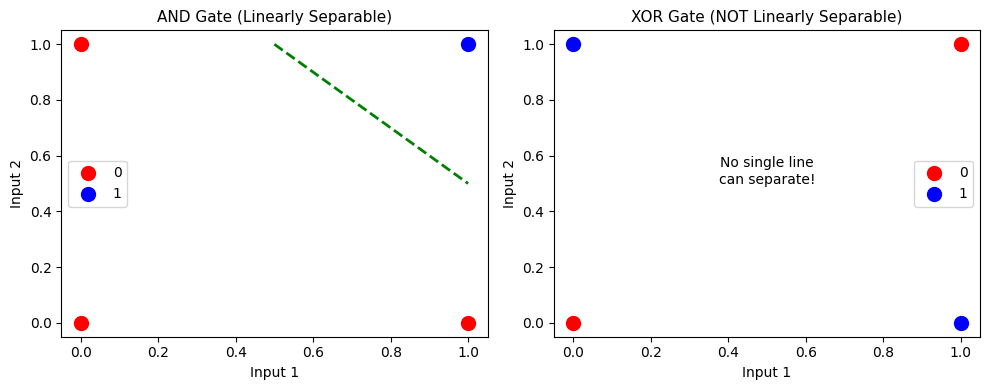

In [11]:
# XOR problem - cannot be solved by a single line!
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# AND - linearly separable
ax = axes[0]
ax.scatter([0, 0, 1], [0, 1, 0], c='red', s=100, label='0')
ax.scatter([1], [1], c='blue', s=100, label='1')
ax.plot([0.5, 1.0], [1.0, 0.5], 'g--', linewidth=2)
ax.set_title('AND Gate (Linearly Separable)', fontsize=11)
ax.set_xlabel('Input 1'); ax.set_ylabel('Input 2')
ax.legend()

# XOR - NOT linearly separable
ax = axes[1]
ax.scatter([0, 1], [0, 1], c='red', s=100, label='0')
ax.scatter([0, 1], [1, 0], c='blue', s=100, label='1')
ax.set_title('XOR Gate (NOT Linearly Separable)', fontsize=11)
ax.set_xlabel('Input 1'); ax.set_ylabel('Input 2')
ax.annotate('No single line\ncan separate!', xy=(0.5, 0.5), fontsize=10, ha='center')
ax.legend()

plt.tight_layout()
plt.show()

The XOR limitation was a major criticism of early neural networks. The solution? **Add more layers!** Multi-layer networks can learn non-linear boundaries.

# 8.4 Teaching Networks to Learn

<img alt="My CPU is a neural net processor, a learning computer" src="../images/L08_arnie_neural_net.png" width="1000" style="display:block;">
<font size=2>"My CPU is a neural net processor, a learning computer. The more contact I have with humans, the more I learn." - The T800 in <i>Terminator 2: Judgement Day (1991)</i></font>

As you can imagine, if a single neuron has many learned parameters (weights and bias), a network of them has many, many more. But out of the box, a neural network is not useful until it is trained -- until those weights have been carefully adjusted and calibrated. Teaching a neural network to learn (to adjust its weights) is an optimization problem.

**The learning problem**: Given training data, find weights that minimize prediction error.

**Loss function**: Measures how wrong our predictions are. For binary classification, we use **binary cross-entropy**:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$


where $\bf{y}$'s are the true class labels and $\bf{\hat{y}}$'s are predicted probabilities.


**Intuition**: Cross-entropy *<font color="blue">heavily penalizes confident wrong predictions</font>*—if you predict 0.99 when the answer is 0, the $\log(1-0.99) = \log(0.01)$ term makes the loss explode. This encourages the network to be calibrated, not just accurate.

In [12]:
def binary_cross_entropy(y_true, y_pred):
    """Calculate binary cross-entropy loss."""
    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Calculate loss for our untrained network
predictions = forward(X_normalized, weights, bias)
loss = binary_cross_entropy(y, predictions)
print(f"Initial loss: {loss:.4f}")

Initial loss: 0.6239


## Gradient Descent Intuition

<img alt="3D visualization of a loss landscape with hills, valleys, local and global minima" src="../images/L08_loss_landscape.png" width="600" style="display:block;">
<font size=2>A 3D loss landscape showing showing gradient descent following the direction of steepest descent, toward lower loss values.</font>

Imagine you're blindfolded on a hilly landscape, trying to find the lowest valley. Your strategy:
1. Feel the slope beneath your feet (compute the **gradient**)
2. Take a step downhill (update weights in the opposite direction of the gradient)
3. Repeat until you reach a valley (minimum loss)

The **learning rate** controls your step size:
- Too large → You might overshoot the minimum
- Too small → Training takes forever

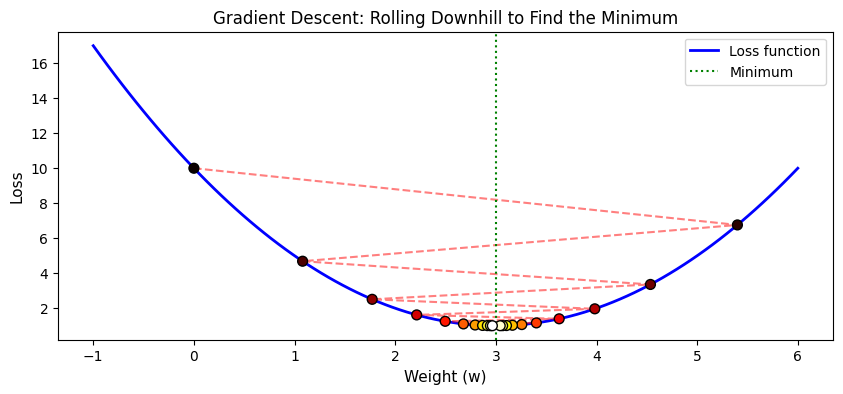

Started at w=0.00, ended at w=2.97 (true minimum is w=3)


In [13]:
# Visualize gradient descent on a simple 1D loss function
def simple_loss(w):
    return (w - 3)**2 + 1  # Minimum at w=3

def simple_gradient(w):
    return 2 * (w - 3)  # Derivative

# Simulate gradient descent
w = 0.0  # Start far from minimum
learning_rate = 0.9
history = [w]

for _ in range(20):
    gradient = simple_gradient(w)
    w = w - learning_rate * gradient  # Update rule!
    history.append(w)

# Plot
w_range = np.linspace(-1, 6, 100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(w_range, simple_loss(w_range), 'b-', linewidth=2, label='Loss function')
ax.scatter(history, [simple_loss(w) for w in history], c=range(len(history)), cmap='hot', edgecolors='k', s=50, zorder=5)
ax.plot(history, [simple_loss(w) for w in history], 'r--', alpha=0.5)
ax.axvline(x=3, color='green', linestyle=':', label='Minimum')
ax.set_xlabel('Weight (w)', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Gradient Descent: Rolling Downhill to Find the Minimum', fontsize=12)
ax.legend()
plt.show()
print(f"Started at w={history[0]:.2f}, ended at w={history[-1]:.2f} (true minimum is w=3)")

## Stochastic Gradient Descent (SGD)

<img alt="Gradient descent is like a drunken walk." src="../images/L08_ET_drunken_walk.png" width="800" style="display:block;">
<font size=2>ET gets drunk (and vicariously, so does Elliot) in <i>E.T. the Extra-Terrestrial (1982)</i></font>

Computing gradients over the **entire** dataset is expensive. Instead, we can only look at a little bit of the data. If Gradient Descent is like a careful mountaneer precisely navigating the landscape efficiently, then **Stochastic Gradient Descent** is a bit like the same person taking a ***drunken walk***... it's approximately in the right direction most of the time:
- **Stochastic GD**: Use one sample at a time (very noisy but very fast) `<drunk and unpredictable>`
- **Mini-batch GD**: Use a small batch (less noisy, still fast)  `<loose and locked-in>`

Mini-batch gradient descent is the standard approach in deep learning.

<!-- Start Exercise 8.3-->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 8.3: One Step of Gradient Descent </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
Given a weight w=5.0 and learning rate=0.2, perform one step of gradient descent on the loss function L(w) = (w-3)² + 1 **.
<ol>
<li>Calculate the gradient at w = 5.0</li>
<li>Apply the update rule: w_new = w - learning_rate × gradient</li>
<li>What is the new weight value?</li>
</ol>
</div>

In [42]:
# Exercise 8.3: One Step of Gradient Descent

w = 5.0
learning_rate = 0.2

# Step 1: Calculate gradient at w=5.0
# Gradient of (w-3)^2 + 1 is 2*(w-3)  (just taking the derivative of a polynomial)
gradient = 2*(w-3)  # REPLACE NONE WITH YOUR CODE HERE

# Step 2: Apply update rule
w_new = w - gradient*learning_rate # REPLACE NONE WITH YOUR CODE HERE

print(f"Initial w: {w}")
print(f"Gradient at w={w}: {gradient}")
print(f"New w after one step: {w_new}")

Initial w: 5.0
Gradient at w=5.0: 4.0
New w after one step: 4.2


<hr/>
<!-- End Exercise 8.3-->

# 8.5 Backpropagation: The Chain Rule in Action

In a multi-layer network, how do we know how to update weights in earlier layers?

<font color="blue">**Backpropagation**</font> uses the chain rule from calculus to efficiently compute gradients for all weights, working backwards from the output.

Backpropagation is all about ***assigning blame***. When the network makes a prediction error, we need to figure out how much each weight contributed to that mistake. Starting from the output, we work backwards through the network, asking: "How much would the loss change if I tweaked this weight slightly?"

The **chain rule** makes this efficient—instead of recalculating everything from scratch for each weight, we can ***reuse intermediate calculations as we propagate the error signal backwards***. It's like a game of telephone in reverse: the output error gets passed back through each layer, with each layer's contribution to the error computed along the way.

**The key insight**: A weight's gradient tells us both the direction (should it increase or decrease?) and magnitude (by how much?) to reduce the error—and backpropagation computes all these gradients in one efficient backward pass.



For our single-layer network, the gradient of the loss with respect to a weight $w_j$ is:

$$\frac{\partial L}{\partial w_j} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i) \cdot x_{ij}$$

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  If you're interested in where the above gradient came from, you can derive it by starting with the loss function (binary cross-entropy) and activation function (sigmoid) and then applying the chain rule:

  $$\hspace{5.5cm} \frac{\partial L}{\partial w_j} =  \frac{\partial L}{\partial \widehat{y} }\cdot\frac{\partial \widehat{y}}{\partial z}\cdot\frac{\partial z}{\partial w_j}$$
  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

In [14]:
def compute_gradients(X, y, weights, bias):
    """
    Compute gradients for weights and bias using backpropagation.
    """
    n_samples = len(y)
    
    # Forward pass
    predictions = forward(X, weights, bias)
    
    # Backward pass - compute gradients
    error = predictions - y  # (n_samples,)
    
    # Gradient for weights: average of (error × input) for each sample
    dw = np.dot(X.T, error) / n_samples  # (n_features,)
    
    # Gradient for bias: average of errors
    db = np.mean(error)
    
    return dw, db

# Example: Compute gradients
dw, db = compute_gradients(X_normalized, y, weights, bias)
print(f"Weight gradients: {dw.round(4)}")
print(f"Bias gradient: {db:.4f}")

Weight gradients: [ 0.2821  0.2814 -0.3556 -0.3439]
Bias gradient: -0.0000


In [15]:
weights

array([ 0.04967142, -0.01382643,  0.06476885,  0.15230299])

## Training Loop: Putting It All Together

In [16]:
def train(X, y, epochs=100, learning_rate=0.5):
    """
    Train a single-layer neural network.
    """
    n_features = X.shape[1]
    
    # Initialize weights randomly
    np.random.seed(42)
    weights = np.random.randn(n_features) * 0.1
    bias = 0.0
    
    losses = []
    
    for epoch in range(epochs):
        # Forward pass
        predictions = forward(X, weights, bias)
        loss = binary_cross_entropy(y, predictions)
        losses.append(loss)
        
        # Backward pass
        dw, db = compute_gradients(X, y, weights, bias)
        
        # Update parameters
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
        
        if epoch % 20 == 0:
            acc = ((predictions > 0.5).astype(int) == y).mean()
            print(f"Epoch {epoch:3d}: Loss={loss:.4f}, Accuracy={acc:.1%}")
    
    return weights, bias, losses

# Train the network!
final_weights, final_bias, losses = train(X_normalized, y, epochs=100, learning_rate=0.5)

Epoch   0: Loss=0.6239, Accuracy=87.5%
Epoch  20: Loss=0.2271, Accuracy=87.5%
Epoch  40: Loss=0.2070, Accuracy=75.0%
Epoch  60: Loss=0.1987, Accuracy=75.0%
Epoch  80: Loss=0.1933, Accuracy=75.0%


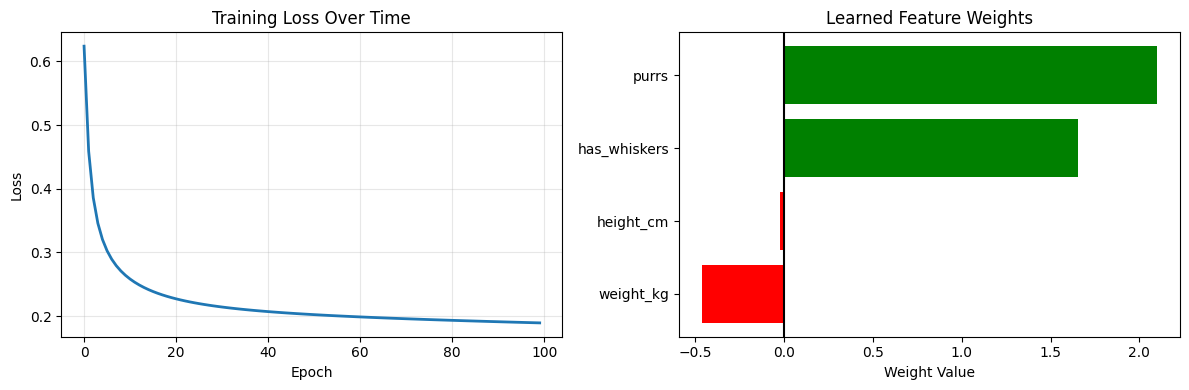


Final predictions:
  Animal 1: pred=0.986, actual=1 ✓
  Animal 2: pred=0.016, actual=0 ✓
  Animal 3: pred=0.986, actual=1 ✓
  Animal 4: pred=0.496, actual=0 ✓
  Animal 5: pred=0.018, actual=0 ✓
  Animal 6: pred=0.985, actual=1 ✓
  Animal 7: pred=0.007, actual=0 ✓
  Animal 8: pred=0.476, actual=1 ✗


In [17]:
# Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].grid(True, alpha=0.3)

# Show learned weights
axes[1].barh(feature_names, final_weights, color=['red' if w < 0 else 'green' for w in final_weights])
axes[1].axvline(x=0, color='black', linestyle='-')
axes[1].set_xlabel('Weight Value')
axes[1].set_title('Learned Feature Weights')

plt.tight_layout()
plt.show()

# Final predictions
print("\nFinal predictions:")
final_preds = forward(X_normalized, final_weights, final_bias)
for i, (pred, actual) in enumerate(zip(final_preds, y)):
    correct = "✓" if (pred > 0.5) == actual else "✗"
    print(f"  Animal {i+1}: pred={pred:.3f}, actual={actual} {correct}")

The network learned that **negative weight** (smaller animals) and **purring** are strong indicators of cats!

<!-- Start Exercise 8.4-->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 8.4: Trace Backpropagation </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">
For a tiny 2-input network with sigmoid activation, trace backpropagation for one sample:
<ul>
<li>Inputs: x = [0.5, 0.8]</li>
<li>Weights: w = [0.3, -0.2]</li>
<li>Bias: b = 0.1</li>
<li>True label: y = 1</li>
</ul>
Calculate:
<ol>
<li>The prediction (forward pass)</li>
<li>The error (prediction - true label)</li>
<li>The gradient for w₁ (error × x₁)</li>
</ol>
</div>

In [ ]:
# Exercise 8.4: Trace Backpropagation 

# Imports
import numpy as np


x = np.array([0.5, 0.8])
w = np.array([0.3, -0.2])
b = 0.1
y_true = 1

# Step 1: Forward pass
z = None # Create the weighted sum here
prediction = None # Apply the activation function (sigmoid) to z here

# Step 2: Calculate error
error = None # Create the error here (difference between the prediction and the true label)

# Step 3: Calculate gradient for w1
dw1 = None # Calculate the gradient for the first weight (w1) here

print(f"Weighted sum (z): {z:.3f}")
print(f"Prediction: {prediction:.3f}")
print(f"Error: {error:.3f}")
print(f"Gradient for w1: {dw1:.3f}")

<hr/>
<!-- End Exercise 8.4-->

# 8.6 Design Choices in Neural Networks

<img alt="Design decisions in Weird Science" src="../images/L08_weird_science_design.png" width="800" style="display:block;">
<font size=2>Gary and Wyatt struggle with their design choices in <i>Weird Science (1985)</i></font>

While we use data to train neural networks, there are ***many decisions we have to make, as the designer*** before we do so. Some choices will restrict what some layers in the network do to make it easier for the network to learn patterns that we know are important.  Other choices will be about selecting activation, loss, and training time choices (e.g., learning curves, dropout) that are appropriate and compatible with our particular prediction problem.  


## Architecture

Which types of layers should we use in our NN?

| Layer Type | What It Does | Best For |
|------------|--------------|----------|
| **Dense (Fully Connected)** | Every neuron connects to all neurons in previous layer | Tabular data, general-purpose |
| **Convolutional (Conv)** | Learns local spatial patterns using sliding filters | Images, spatial data |
| **Recurrent (RNN/LSTM/GRU)** | Maintains memory of previous inputs in sequence | Text, time series, sequences |
| **Dropout** | Randomly "turns off" neurons during training | Regularization (prevents overfitting) |
| **Batch Normalization** | Normalizes layer inputs to stabilize training | Faster training, deeper networks |
| **Embedding** | Converts categorical tokens to dense vectors | Text, categorical features |
| **Attention/Transformer** | Learns which parts of input to focus on | NLP, modern LLMs, long sequences |
| **Pooling (Max/Avg)** | Downsamples by taking max or average over regions | Reducing spatial dimensions (images) |

**The key insight**: Different layer types encode different *assumptions* about your data—convolutional layers assume local spatial patterns matter, recurrent layers assume sequence order matters, and dense layers make no such assumptions (but need more data to learn structure).


## Activation Functions

| Function | Use Case | Watch Out For |
|----------|----------|---------------|
| **ReLU** | Hidden layers (default choice) | "Dead neurons" (output always 0) |
| **Sigmoid** | Binary classification output | Vanishing gradients in hidden layers |
| **Softmax** | Multi-class classification output | — |
| **Tanh** | Alternative to sigmoid | Still has vanishing gradients |

## Loss Functions

| Task | Loss Function |
|------|---------------|
| Regression | Mean Squared Error (MSE) |
| Binary Classification | Binary Cross-Entropy |
| Multi-class Classification | Categorical Cross-Entropy |

## Optimizers

| Optimizer | Description |
|-----------|-------------|
| **SGD** | Classic, simple, but can be slow |
| **Momentum** | Adds "inertia" to escape local minima |
| **Adam** | Adaptive learning rates, usually works well out of the box |

Epoch   0: Loss=0.6239, Accuracy=87.5%
Epoch  20: Loss=0.5540, Accuracy=87.5%
Epoch  40: Loss=0.5016, Accuracy=87.5%
Epoch  60: Loss=0.4616, Accuracy=87.5%
Epoch  80: Loss=0.4303, Accuracy=87.5%
Epoch   0: Loss=0.6239, Accuracy=87.5%
Epoch  20: Loss=0.3304, Accuracy=87.5%
Epoch  40: Loss=0.2754, Accuracy=87.5%
Epoch  60: Loss=0.2514, Accuracy=87.5%
Epoch  80: Loss=0.2375, Accuracy=87.5%
Epoch   0: Loss=0.6239, Accuracy=87.5%
Epoch  20: Loss=0.2271, Accuracy=87.5%
Epoch  40: Loss=0.2070, Accuracy=75.0%
Epoch  60: Loss=0.1987, Accuracy=75.0%
Epoch  80: Loss=0.1933, Accuracy=75.0%
Epoch   0: Loss=0.6239, Accuracy=87.5%
Epoch  20: Loss=0.1935, Accuracy=75.0%
Epoch  40: Loss=0.1797, Accuracy=87.5%
Epoch  60: Loss=0.1695, Accuracy=100.0%
Epoch  80: Loss=0.1613, Accuracy=100.0%


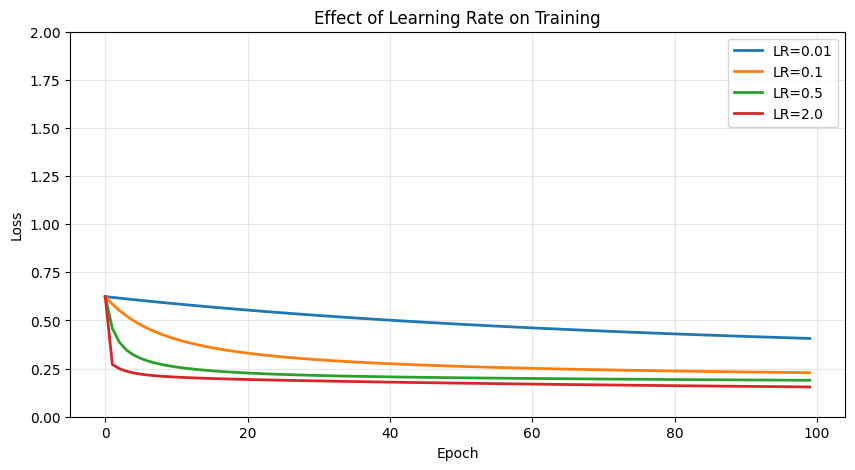

In [18]:
# Visualize how different learning rates affect training
learning_rates = [0.01, 0.1, 0.5, 2.0]

fig, ax = plt.subplots(figsize=(10, 5))

for lr in learning_rates:
    _, _, losses = train(X_normalized, y, epochs=100, learning_rate=lr)
    ax.plot(losses, label=f'LR={lr}', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Effect of Learning Rate on Training')
ax.legend()
ax.set_ylim(0, 2)  # Limit y-axis for visibility
ax.grid(True, alpha=0.3)
plt.show()

Notice how:
- **LR=0.01**: Too slow, barely learning
- **LR=0.1**: Steady progress
- **LR=0.5**: Fast convergence
- **LR=2.0**: Unstable, may diverge

# Summary

In this lecture, we covered the foundations of neural networks:

## From Biology to Math
- Artificial neurons are inspired by biological neurons
- A neuron computes: $y = f(\sum w_i x_i + b)$
- Non-linear activation functions give networks their power

## Learning Algorithms
- **Loss functions** measure prediction error
- **Gradient descent** minimizes loss by iteratively updating weights
- **Backpropagation** efficiently computes gradients using the chain rule

## Design Choices
- Architecture, activation functions, loss functions, and optimizers all affect performance
- There's no one-size-fits-all solution—experimentation is key

## Key Equations

| Concept | Equation |
|---------|----------|
| Neuron output | $y = f(\mathbf{w} \cdot \mathbf{x} + b)$ |
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| Cross-entropy loss | $L = -\frac{1}{n}\sum[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]$ |
| Weight update | $w_{new} = w_{old} - \alpha \cdot \frac{\partial L}{\partial w}$ |

## Key Takeaways
<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
  display: flex;
  align-items: flex-start;
">
  <div style="
    font-size: 60pt;
    line-height: 1;
    width: 48px;
    display: flex;
    align-items: flex-start;
  ">
    🎯
  </div>
<div style="padding: 0px; margin:0 0 0 60px;">

- **Neural networks are mathematical models** inspired by biology, not replicas of the brain
- **The power comes from composition** - stacking simple neurons creates complex functions
- **Backpropagation + gradient descent = learning** - this combination revolutionized AI
- **Design choices matter** - there's no universal best architecture or hyperparameters
- **Start simple** - add complexity only when needed

</div>
</div>

## Extended Learning Resources

For a deeper, more visual understanding, I highly recommend Grant Sanderson's (3Blue1Brown) neural network series:

1. **[What is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk)** (19 min) - Beautiful visual introduction
2. **[Gradient descent, how neural networks learn](https://www.youtube.com/watch?v=IHZwWFHWa-w)** (21 min) - Intuitive gradient descent explanation
3. **[What is backpropagation really doing?](https://www.youtube.com/watch?v=Ilg3gGewQ5U)** (14 min) - Conceptual backpropagation
4. **[Backpropagation calculus](https://www.youtube.com/watch?v=tIeHLnjs5U8)** (10 min) - Mathematical details

# Your Turn: Questions, Reactions, and Feedback

As always, I'd like to hear your thoughts on this material:

1. What concepts were most new or surprising to you?

2. What would you like to see explained in more depth?

3. Any questions that came up as you worked through the notebook?

4. How does your intuition about neural networks compare to what you learned today?

**Write your thoughts below:**

*[Your reflections here]*